In [1]:
import tensorflow as tf 
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
print(tf.__version__)
print(tf.test.is_gpu_available())

2.10.0
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
True


In [3]:
# from sklearn.model_selection import GridSearchCV
# from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_curve, auc
# from sklearn import svm
# from sklearn.ensemble import RandomForestClassifier
# from src.processing import Processing
import config
# from sklearn.feature_selection import SelectKBest, chi2
# import matplotlib.pyplot as plt
# import seaborn as sns
# import joblib
# import pandas as pd
# import numpy as np
# from imblearn.over_sampling import SMOTE
# from imblearn.under_sampling import RandomUnderSampler
import warnings
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_curve, auc
import random
# from src.datasplitting import DataSplitting
warnings.filterwarnings('ignore')
# from sklearn.model_selection import GridSearchCV, PredefinedSplit, TimeSeriesSplit
# # from sklearn.metrics import (
# #     accuracy_score, f1_score, precision_score, recall_score,
# #     confusion_matrix, roc_auc_score, precision_recall_curve, auc, classification_report
# )
# from src.processing import Processing
# from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score
# from sklearn.decomposition import PCA
# from sklearn.neighbors import KNeighborsClassifier
# from imblearn.under_sampling import EditedNearestNeighbours
# from imblearn.pipeline import make_pipeline, Pipeline
# from sklearn.preprocessing import StandardScaler
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
import os
# from imblearn.over_sampling import SMOTE
# from collections import Counter
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
import os
import gc

from tfrecordhandlerDL import TFRecordDataHandlerDL

# from tfrecordhandler import TFRecordDataHandler
# from src.datasplitting_for_images import DataSplittingForImages

In [4]:
import matplotlib.pyplot as plt
import numpy as np
def visualize_data(image_batch, mask_batch, num_samples=4):
    plt.figure(figsize=(10, num_samples * 2))
    for i in range(num_samples):
        # Imagen en escala de grises
        plt.subplot(num_samples, 2, 2 * i + 1)
        plt.imshow(np.squeeze(image_batch[i]), cmap='gray')
        plt.title(f"Image {i}")
        plt.axis('off')

        # Máscara correspondiente
        plt.subplot(num_samples, 2, 2 * i + 2)
        plt.imshow(np.squeeze(mask_batch[i]), cmap='gray')
        plt.title(f"Mask {i}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()


In [5]:
# Definir hiperparámetros
INPUT_DIR = 'input/deep_learning'
batch_size = 32
n_epochs = 10
checkpoint = './best_model_vgg.h5'
shuffle = True
verbose = 1

In [6]:
# def _bytes_feature(value):
#     """Returns a bytes_list from a string / byte."""
#     return tf.train.Feature(bytes_list=tf.train.BytesList(value=[value]))

# def _int64_feature(value):
#     """Returns an int64_list from a bool / enum / int / uint."""
#     return tf.train.Feature(int64_list=tf.train.Int64List(value=[value]))

# def serialize_example(image_path, mask_path):
#     img = tf.io.decode_image(tf.io.read_file(image_path), channels=3)
#     img_bytes = img.numpy().tobytes()

#     mask = tf.io.decode_image(tf.io.read_file(mask_path), channels=1)
#     mask_bytes = mask.numpy().tobytes()

#     # Get Study, Mice group and Day of study from the path
#     path = os.path.normpath(mask_path)
    
#     # Divide el path en partes
#     path_parts = path.split(os.sep)

#     # Extraer las partes relevantes
#     # 0 for Cured Mice, 1 for Relapsing Mice, 2 for Control Mice
#     if path_parts[2] == 'Cured mice':
#         group_name = 1
#     elif path_parts[2] == 'IMS-TMS-TREATED-RELAPSING':
#         group_name = 0
#     elif path_parts[2] == 'Control':
#         group_name = 0
#     else:
#         print(path_parts)
#         raise ValueError('Invalid group')
#     mouse_id = path_parts[3]       # 'C1281'
#     day_of_study = path_parts[4]   # 'day10'

#     # Get only the integers in ids
#     mouse_id = mouse_id[1:]
#     day_of_study = day_of_study[3:]

#     feature = {
#         'image': _bytes_feature(img_bytes),
#         'mask': _bytes_feature(mask_bytes),
#         'height': _int64_feature(img.shape[0]),
#         'width': _int64_feature(img.shape[1]),
#         'mask_height': _int64_feature(mask.shape[0]),
#         'mask_width': _int64_feature(mask.shape[1]),
#         'group_name': _int64_feature(int(group_name)),
#         'mouse_id': _int64_feature(int(mouse_id)),
#         'day_of_study': _int64_feature(int(day_of_study))
#     }
    
#     return tf.train.Example(features=tf.train.Features(feature=feature)).SerializeToString()

# def create_tfrecord(file_paths, output_file):
#     with tf.io.TFRecordWriter(output_file) as writer:
#         for img_path, mask_path in file_paths:
#             # print(f"Writing {img_path} and {mask_path} to {output_file}")
            
#             if not os.path.exists(img_path) or not os.path.exists(mask_path):
#                 print(f'Image or mask not found: {img_path}, {mask_path}')
#                 continue

#             try:
#                 example = serialize_example(img_path, mask_path)
#                 writer.write(example)
#             except Exception as e:
#                 print(f"Error serializing {img_path}, {mask_path}: {e}")

# def split_dataset_by_m_id(root_dir, train_ratio=0.8):
#     mouse_to_data = {}
    
#     # Recorrer todas las imágenes y máscaras
#     for data_group in os.listdir(root_dir):
#         data_group_path = os.path.join(root_dir, data_group)
#         if not os.path.isdir(data_group_path):
#             continue
#         for mice_group in os.listdir(data_group_path):
#             mice_group_path = os.path.join(data_group_path, mice_group)
#             if not os.path.isdir(mice_group_path):
#                 continue  # Saltar si no es un directorio
#             for dayofstudy in os.listdir(mice_group_path):
#                 dayofstudy_path = os.path.join(mice_group_path, dayofstudy)
#                 if not os.path.isdir(dayofstudy_path):
#                     continue  # Saltar si no es un directorio
#                 mri_imgs = os.path.join(dayofstudy_path, 'MRI images')
#                 if not os.path.exists(mri_imgs):
#                     print(f"No se encontró la carpeta {mri_imgs}")
#                     continue
#                 # Número de imágenes
#                 n_imgs = len(os.listdir(mri_imgs))
#                 for i in range(n_imgs):
#                     img_path = os.path.join(mri_imgs, f'image_s{i + 1}.jpg')
#                     mask_path = os.path.join(dayofstudy_path, f'Mask s{i + 1}.jpg')
                    
#                     # Get Study, Mice group and Day of study from the path
#                     path = os.path.normpath(mask_path)
                    
#                     # Divide el path en partes
#                     path_parts = path.split(os.sep)

#                     # Extraer las partes relevantes
#                     # 0 for Relapsing Mice, 1 for Cured Mice, 2 for Control Mice
#                     if path_parts[2] == 'Cured mice':
#                         group_name = 1
#                     elif path_parts[2] == 'IMS-TMS-TREATED-RELAPSING':
#                         group_name = 0
#                     elif path_parts[2] == 'Control':
#                         group_name = 2
#                     else:
#                         raise ValueError('Invalid group')
                    
#                     mouse_id = path_parts[3]       # 'C1281'
#                     day_of_study = path_parts[4]   # 'day10'

#                     # Get only the integers in ids
#                     mouse_id = mouse_id[1:]  # Remove 'C'
#                     day_of_study = day_of_study[3:]  # Remove 'day'
                    
#                     # Append data to mouse ID group
#                     if mouse_id not in mouse_to_data and group_name != 2:
#                         mouse_to_data[mouse_id] = []
#                     if group_name != 2:
#                         mouse_to_data[mouse_id].append((img_path, mask_path, group_name, mouse_id, day_of_study))

#     print(mouse_to_data)

#     test_ids = ['1276', '1281', '1263', '1264'] # Two cured and two relapsing mice
#     # train_ids = ['1284', '1285', '1382', '1270', '1380', '1383', 'C1258', 'C1260', 'C1261', 'C1297', 'C1299', 'C1359', 'C1360', 'C1361'] # Three cured and three relapsing mice (1284, 1285, 1382), (1270, 1380, 1383)
#     train_ids = ['1284', '1285', '1382', '1270', '1380', '1383','1276', '1281', '1263', '1264']
#     print(f"Train IDs: {train_ids}")
#     print(f"Test IDs: {test_ids}")

#     train_mice = [mice for k, mice in mouse_to_data.items() if k in train_ids]
#     test_mice = [mice for k, mice in mouse_to_data.items() if k in test_ids]

#     print(f"Train mice: {train_mice}")
#     print(f"Test mice: {test_mice}")

#     # # If the train set doesn't have a cured mouse, move one from test
#     # # if not any(mouse_id in train_mice for mouse_id in cured_mice):
#     # #     train_mice.add(cured_mice[0])
#     # #     test_mice.remove(cured_mice[0])

#     # # # If the test set doesn't have a cured mouse, move one from train
#     # # if not any(mouse_id in test_mice for mouse_id in cured_mice):
#     # #     test_mice.add(cured_mice[0])
#     # #     train_mice.remove(cured_mice[0])

#     # # Check that both train and test sets have a cured mouse
#     # print(f'Train mice: {train_mice}')
#     # print(f'Test mice: {test_mice}')

#     # # Assign data to train and test sets
#     # train_data = [data for mouse_id in train_mice for data in mouse_to_data[mouse_id]]
#     # test_data = [data for mouse_id in test_mice for data in mouse_to_data[mouse_id]]

#     train_paths = [(img, mask) for mouse_data in train_mice for img, mask, *_ in mouse_data]
#     test_paths = [(img, mask) for mouse_data in test_mice for img, mask, *_ in mouse_data]

#     print(f"Train paths: {train_paths}")
#     print(f"Test paths: {test_paths}")
    
#     print(f"Total data: {len(train_paths) + len(test_paths)}")
#     print(f"Train data: {len(train_paths)}")
#     print(f"Test data: {len(test_paths)}")
    
#     return train_paths, test_paths


In [7]:
# train_data, test_data = split_dataset_by_m_id(config.DATASET_DIR, train_ratio=0.7)
# train_tfrefcord = os.path.join(INPUT_DIR, 'train_new.tfrecord')
# # test_tfrefcord = os.path.join(INPUT_DIR, 'test_split.tfrecord')

# create_tfrecord(train_data, train_tfrefcord)
# # create_tfrecord(test_data, test_tfrefcord)

In [8]:
# train_tfrefcord = os.path.join(INPUT_DIR, 'train_split.tfrecord')
# test_tfrefcord = os.path.join(INPUT_DIR, 'test_split.tfrecord')

# train_tfrefcord = "input/tfrecord_dataset/full_ds.tfrecord"
# train_tfrefcord = os.path.join(INPUT_DIR, 'train_new.tfrecord')
train_tfrefcord = os.path.join(INPUT_DIR, 'full_ds_fixed_no_control.tfrecord')



Number of train samples: 298
Number of batches: 9
Images min: 0.0, max: 255.0


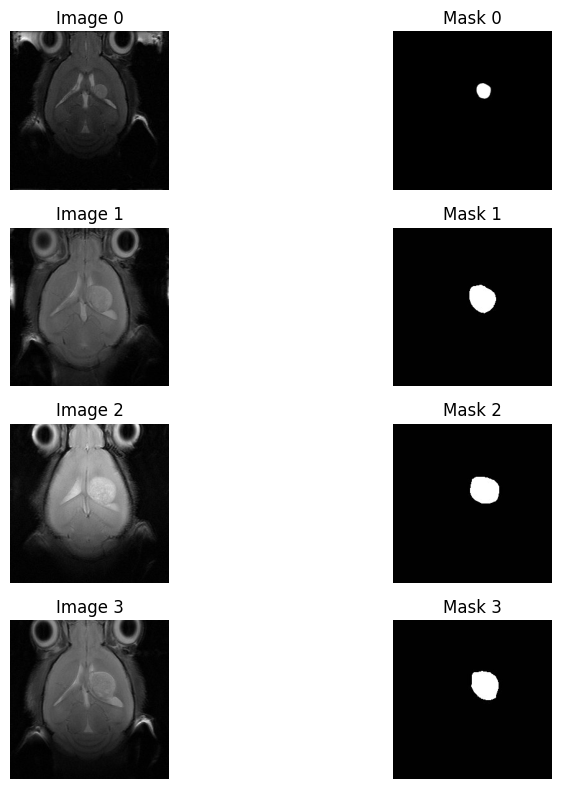

In [9]:
# train_ds_handler = TFRecordImageHandler(train_tfrefcord, batch_size=batch_size, shuffle=False, augment=False)
# train_ds_handler = TFRecordMultimodalHandler(train_tfrefcord, batch_size=batch_size, shuffle=False, augment=False)
train_ds_handler = TFRecordDataHandlerDL(train_tfrefcord, batch_size=batch_size, shuffle=False, augment=False)
train_ds = train_ds_handler.dataset
print(f"Number of train samples: {train_ds_handler.length}")

# test_ds_handler = TFRecordImageHandler(test_tfrefcord, batch_size=batch_size, shuffle=False, augment=False)
# test_ds = test_ds_handler.dataset
# print(f"Number of test samples: {test_ds_handler.length}")

# Number of batches
n_batches = train_ds_handler.length // batch_size
print(f"Number of batches: {n_batches}")

images_tf, masks_tf, group_names, mouse_ids, days_of_study = next(iter(train_ds))

# Check if images are normalized
print(f"Images min: {images_tf.numpy().min()}, max: {images_tf.numpy().max()}")

visualize_data(images_tf, masks_tf, num_samples=4)
#visualize_data(images_tf, group_name_batches, num_samples=15)

# Count instances of each group for each batch
# group_name_counts = {}
# for batch in train_ds:
#     _, _, group_names, _, _ = batch
#     for group in group_names.numpy():
#         if group not in group_name_counts:
#             group_name_counts[group] = 0
#         group_name_counts[group] += 1
# print(f"Group name counts: {group_name_counts}")

In [10]:
SEED = 42
tf.random.set_seed(SEED)

# Data augmentation
def augment_data(image, mask, label, mouse_ids, days_of_study):
    seed = tf.random.uniform([], maxval=10000, dtype=tf.int32)

    # Aplica la misma transformación a imagen y máscara
    image = tf.image.stateless_random_flip_left_right(image, seed=[seed, 1])
    mask = tf.image.stateless_random_flip_left_right(mask, seed=[seed, 1])
    
    image = tf.image.stateless_random_brightness(image, max_delta=0.2, seed=[seed, 2])
    image = tf.image.stateless_random_contrast(image, lower=0.8, upper=1.2, seed=[seed, 3])
    image = tf.image.stateless_random_saturation(image, lower=0.8, upper=1.2, seed=[seed, 4])
    image = tf.image.stateless_random_hue(image, max_delta=0.05, seed=[seed, 5])
    image = tf.clip_by_value(image, 0.0, 1.0)

    return image, mask, label, mouse_ids, days_of_study


# Contador robusto
def count_instances(dataset):
    return sum(1 for _ in dataset)

# Oversampling + batching
import tensorflow as tf

def balance_minority_class_to_majority(dataset, minority_class=1):
    unbatched_ds = dataset  # Ya está sin batch

    # Separar clases
    minority_ds = unbatched_ds.filter(lambda img, mask, lbl, mouse_id, day: tf.squeeze(lbl) == minority_class)
    majority_ds = unbatched_ds.filter(lambda img, mask, lbl, mouse_id, day: tf.squeeze(lbl) != minority_class)

    print("Majority cardinality before:", majority_ds.cardinality())
    print("Minority cardinality before:", minority_ds.cardinality())


    # Repetir el minoritario infinitamente
    minority_ds = minority_ds.repeat()

    # Mezclar ambos datasets de forma balanceada
    balanced_ds = tf.data.Dataset.sample_from_datasets(
        [majority_ds, minority_ds],
        weights=[0.5, 0.5],  # puedes ajustar si quieres más o menos oversampling
        seed=42
    )

    print("✅ Datasets balanceados correctamente")



    return balanced_ds







In [11]:
# # Print shape of images and masks
# print(f"Images shape: {images_tf.shape}")

In [12]:
import os
import random
import tensorflow as tf
import numpy as np
import time
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from sklearn.model_selection import LeaveOneGroupOut
import xgboost as xgb
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, roc_auc_score

# 🔒 Fijar seeds
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# 📌 Inicializar modelo base (input sin forzar a 3 canales)
input_layer = tf.keras.layers.Input(shape=(256, 256, 1), name="input_layer")  # 1 canal

# Para EfficientNetB0 normalmente se esperan 3 canales, pero puedes hacer un pequeño "workaround":
# duplicamos el único canal a 3 internamente en la entrada al modelo
x = tf.keras.layers.Concatenate()([input_layer, input_layer, input_layer])  # De (256,256,1) a (256,256,3)

# Base model
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_tensor=x)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
output_layer = layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)

# 🔍 Feature extractor
feature_extractor = models.Model(inputs=input_layer, outputs=x)

# ✅ Comprobar GPU
print("===> Dispositivos disponibles:")
print(tf.config.list_physical_devices('GPU'))

# ✅ Función para extraer features + tiempos
def extract_features_labels_from_subset(dataset, allowed_days):
    start_time = time.time()
    print("\n[INFO] Extrayendo features...")

    x_all, masks_all, labels_all, mouse_ids_all, days_all = [], [], [], [], []

    for batch in dataset:
        x_batch, masks_tf, y_batch, mouse_ids, days_of_study = batch
        days_np = days_of_study.numpy()

        # Filtrar días permitidos
        mask_days = np.isin(days_np, allowed_days)
        if not np.any(mask_days):
            continue
        mask_days = tf.reshape(mask_days, [-1])

        # Aplicar máscara de días
        x_batch = tf.boolean_mask(x_batch, mask_days)
        masks_tf = tf.boolean_mask(masks_tf, mask_days)
        y_batch = tf.boolean_mask(y_batch, mask_days)
        mouse_ids = tf.boolean_mask(mouse_ids, mask_days)
        days_of_study = tf.boolean_mask(days_of_study, mask_days)

        masks_tf = masks_tf / 255.0

        # --- Invertir las máscaras ---
        inverted_masks = 1.0 - masks_tf  # Asumiendo normalización [0,1]

        # NO se convierte a RGB, se deja tal cual
        x_all.append(x_batch)
        masks_all.append(masks_tf)
        labels_all.append(y_batch.numpy())
        mouse_ids_all.append(mouse_ids.numpy())
        days_all.append(days_of_study.numpy())

    if not x_all:
        return None, None, None, None

    x_all = tf.concat(x_all, axis=0)
    masks_all = tf.concat(masks_all, axis=0)

    print(f"[INFO] Extrayendo features con feature_extractor...")
    time_before_predict = time.time()
    X = feature_extractor.predict(x_all, verbose=1, batch_size=128)
    time_after_predict = time.time()

    y = np.concatenate(labels_all, axis=0)
    mouse_ids = np.concatenate(mouse_ids_all, axis=0)
    days = np.concatenate(days_all, axis=0)

    total_time = time.time() - start_time
    predict_time = time_after_predict - time_before_predict

    print(f"\n✅ Tiempo total extracción: {total_time:.2f} seg")
    print(f"⏳ Tiempo solo predict: {predict_time:.2f} seg")

    return X, y, mouse_ids, days

# --- CONFIGURACIONES DEL DATASET ---
batch_size = 4

# 📌 Preparar dataset
train_ds = train_ds.unbatch().batch(batch_size).prefetch(tf.data.AUTOTUNE)

# 📌 Días únicos
all_days = []
for batch in train_ds:
    _, _, _, _, days_of_study = batch
    all_days.extend(days_of_study.numpy())
all_days = np.array(all_days)
all_days.sort()

# 📌 Extraer features
all_features, all_labels, all_mouse_ids, all_days_array = extract_features_labels_from_subset(train_ds, allowed_days=np.unique(all_days))

if all_features is None:
    raise ValueError("No se pudieron extraer los features globales.")

# 🔥 Arreglar shapes
all_labels = np.squeeze(all_labels)
all_mouse_ids = np.squeeze(all_mouse_ids)
all_days_array = np.squeeze(all_days_array)

# 📌 Asegurar tipo string en mouse_ids
if isinstance(all_mouse_ids[0], bytes):
    all_mouse_ids = np.array([m.decode("utf-8") for m in all_mouse_ids])

# --- Leave-One-Group-Out (mouse) ---
logo = LeaveOneGroupOut()

# 📈 Acumuladores globales
all_y_true, all_y_pred, all_y_proba = [], [], []
all_mouse_ids_pred, all_days_pred = [], []

# --- LOOP Leave-One-Mouse-Out ---
for fold, (train_idx, test_idx) in enumerate(logo.split(all_features, all_labels, groups=all_mouse_ids)):
    print(f"\n🐭 Fold {fold+1}")

    mouse_ids_train = np.unique(all_mouse_ids[train_idx])
    mouse_ids_test = np.unique(all_mouse_ids[test_idx])

    X_train, y_train = all_features[train_idx], all_labels[train_idx]
    X_test, y_test = all_features[test_idx], all_labels[test_idx]

    # 💥 Balanceo en train
    pos_idx = np.where(y_train == 1)[0]
    neg_idx = np.where(y_train == 0)[0]

    if len(pos_idx) == 0 or len(neg_idx) == 0:
        print("❌ Fold ignorado por falta de clases.")
        continue

    if len(pos_idx) < len(neg_idx):
        pos_idx_oversampled = np.random.choice(pos_idx, size=len(neg_idx), replace=True)
        X_train_balanced = np.concatenate([X_train[neg_idx], X_train[pos_idx_oversampled]], axis=0)
        y_train_balanced = np.concatenate([y_train[neg_idx], y_train[pos_idx_oversampled]], axis=0)
    else:
        X_train_balanced = X_train
        y_train_balanced = y_train

    # Shuffle
    shuffle_idx = np.random.permutation(len(y_train_balanced))
    X_train_balanced = X_train_balanced[shuffle_idx]
    y_train_balanced = y_train_balanced[shuffle_idx]

    print(f"[Fold {fold+1}] Shape X_train_balanced: {X_train_balanced.shape} | X_test: {X_test.shape}")

    # --- Entrenar XGBoost ---
    xgb_clf = xgb.XGBClassifier(
        n_estimators=100,
        learning_rate=0.01,
        max_depth=3,
        subsample=0.6,
        colsample_bytree=0.6,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    )
    xgb_clf.fit(X_train_balanced, y_train_balanced)

    # Predicciones
    y_proba = xgb_clf.predict_proba(X_test)[:, 1]
    y_pred = xgb_clf.predict(X_test)

    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    all_y_proba.extend(y_proba)

    all_mouse_ids_pred.extend(all_mouse_ids[test_idx])  # 👈 aquí guardamos los mouse_ids del test
    all_days_pred.extend(all_days_array[test_idx])  

    # --- Resultados por fold ---
    acc_fold = accuracy_score(y_test, y_pred)
    print(f"✅ Accuracy fold {fold+1}: {acc_fold:.4f}")
    # Mostrar dias en los que hay predicciones erróneas
    errores_idx = np.where(y_test != y_pred)[0]
    print(f"❌ Errores detectados en fold {fold+1}:")
    for idx in errores_idx:
        print(f"Mouse ID: {all_mouse_ids[test_idx][idx]} | Day: {all_days_array[test_idx][idx]} | True: {y_test[idx]} | Pred: {y_pred[idx]}")
    # Mostrar dias bien predichos
    print(f"✅ Predicciones correctas en fold {fold+1}:")
    for idx in range(len(y_test)):
        if y_test[idx] == y_pred[idx]:
            print(f"Mouse ID: {all_mouse_ids[test_idx][idx]} | Day: {all_days_array[test_idx][idx]} | True: {y_test[idx]} | Pred: {y_pred[idx]}")


# --- Resultados Finales ---
all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)
all_y_proba = np.array(all_y_proba)
all_mouse_ids_pred = np.array(all_mouse_ids_pred)
all_days_pred = np.array(all_days_pred)

acc_global = accuracy_score(all_y_true, all_y_pred)
auc_global = roc_auc_score(all_y_true, all_y_proba)
tn, fp, fn, tp = confusion_matrix(all_y_true, all_y_pred).ravel()
sensitivity_global = tp / (tp + fn)
specificity_global = tn / (tn + fp)
precision_global = tp / (tp + fp) if (tp + fp) > 0 else 0
npv_global = tn / (tn + fn) if (tn + fn) > 0 else 0
f1_macro_global = f1_score(all_y_true, all_y_pred, average='macro')
f1_weighted_global = f1_score(all_y_true, all_y_pred, average='weighted')

# 🎯 Identificar fallos
errores_idx = np.where(all_y_true != all_y_pred)[0]

print("\n❌ Errores detectados:")
for idx in errores_idx:
    print(f"Mouse ID: {all_mouse_ids_pred[idx]} | Day: {all_days_pred[idx]} | True: {all_y_true[idx]} | Pred: {all_y_pred[idx]}")

# Mostrar dias bien predichos
print("\n✅ Predicciones correctas:")
for idx in range(len(all_y_true)):
    if all_y_true[idx] == all_y_pred[idx]:
        print(f"Mouse ID: {all_mouse_ids_pred[idx]} | Day: {all_days_pred[idx]} | True: {all_y_true[idx]} | Pred: {all_y_pred[idx]}")


print("\n📈 Resultados Finales Globales:")
print(f"✅ Accuracy Global: {acc_global:.4f}")
print(f"📊 AUC Global: {auc_global:.4f}")
print(f"🔍 Sensitivity (Recall+): {sensitivity_global:.4f} | Specificity (Recall−): {specificity_global:.4f}")
print(f"📌 Precision (PPV): {precision_global:.4f} | NPV: {npv_global:.4f}")
print(f"📏 F1 Macro: {f1_macro_global:.4f} | F1 Weighted: {f1_weighted_global:.4f}")
print(f"🟢 TP: {tp}, 🟡 FP: {fp}, 🔴 FN: {fn}, 🔵 TN: {tn}")


===> Dispositivos disponibles:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

[INFO] Extrayendo features...
[INFO] Extrayendo features con feature_extractor...
3/3 [==============================] - 2s 64ms/step

✅ Tiempo total extracción: 3.10 seg
⏳ Tiempo solo predict: 2.44 seg

🐭 Fold 1
[Fold 1] Shape X_train_balanced: (352, 256) | X_test: (56, 256)
✅ Accuracy fold 1: 0.7321
❌ Errores detectados en fold 1:
Mouse ID: 1263 | Day: 14 | True: 0 | Pred: 1
Mouse ID: 1263 | Day: 19 | True: 0 | Pred: 1
Mouse ID: 1263 | Day: 21 | True: 0 | Pred: 1
Mouse ID: 1263 | Day: 23 | True: 0 | Pred: 1
Mouse ID: 1263 | Day: 23 | True: 0 | Pred: 1
Mouse ID: 1263 | Day: 25 | True: 0 | Pred: 1
Mouse ID: 1263 | Day: 25 | True: 0 | Pred: 1
Mouse ID: 1263 | Day: 29 | True: 0 | Pred: 1
Mouse ID: 1263 | Day: 31 | True: 0 | Pred: 1
Mouse ID: 1263 | Day: 31 | True: 0 | Pred: 1
Mouse ID: 1263 | Day: 33 | True: 0 | Pred: 1
Mouse ID: 1263 | Day: 33 | True: 0 | Pred: 1
Mouse ID: 1263 | Day: 35 |

In [13]:
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def evaluate_model(model, dataset, dataset_name=""):
    y_true = []
    y_pred = []

    for images, labels in dataset:
        preds = model.predict(images)
        y_true.extend(labels.numpy().astype(int))
        y_pred.extend((preds > 0.5).astype(int).flatten())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    f1 = f1_score(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)

    print(f"\n--- Métricas en el conjunto de {dataset_name} ---")
    print(f'Accuracy: {acc:.4f}')
    print(f'F1 Score: {f1:.4f}')
    print(f'Sensitivity (Recall/TPR): {sensitivity:.4f}')
    print(f'Specificity (TNR): {specificity:.4f}')
    print(f'PPV (Precision): {ppv:.4f}')
    print(f'NPV: {npv:.4f}')

    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=["Clase 0", "Clase 1"])
    plt.title(f"Matriz de confusión - {dataset_name}")
    plt.show()

# model = tf.keras.models.load_model(model, custom_objects={'f1_macro': f1_macro})
# Evaluar en test y train
# evaluate_model(model, test_ds, dataset_name="test")
evaluate_model(model, train_ds, dataset_name="train")


ValueError: too many values to unpack (expected 2)

In [ ]:
model_save_path = "output/dl/best_model.keras"

model = tf.keras.models.load_model(model_save_path)

In [ ]:
for layer in model.layers:
    print(layer.name)

In [ ]:
from src.notebooks.dl.gradcam import GradCAM
import matplotlib.pyplot as plt
import numpy as np
import cv2

for image_batch, labels_batch in test_ds:
    batch_size = image_batch.shape[0]
    fig, axes = plt.subplots(5, batch_size, figsize=(3 * batch_size, 10))

    for i, (image, label) in enumerate(zip(image_batch, labels_batch)):
        image = image.numpy()  # Convertir tensor a NumPy array
        label = int(label.numpy())  # Asegurar que la etiqueta sea un entero

        # Imagen en escala de grises
        axes[0, i].imshow(np.squeeze(image[:, :, 0]), cmap='gray')
        axes[0, i].set_title(f"Image, label: {label}")
        axes[0, i].axis('off')

        # Máscara
        axes[1, i].imshow(np.squeeze(image[:, :, 1]), cmap='gray')
        axes[1, i].set_title("Mask")
        axes[1, i].axis('off')

        # GradCAM Heatmap
        gradcam = GradCAM(model, classIdx=label, layerName='block5_conv3')
        heatmap = gradcam.compute_heatmap(np.expand_dims(image, axis=0))
        axes[2, i].imshow(heatmap, cmap='jet')
        axes[2, i].set_title("GradCAM Heatmap")
        axes[2, i].axis('off')

        # GradCAM Overlay en imagen original
        grayscale_image = (image[:, :, 0] * 255).astype(np.uint8)  # Convertir a escala de grises uint8
        grayscale_image = cv2.cvtColor(grayscale_image, cv2.COLOR_GRAY2RGB)  # Convertir a RGB
        overlay = gradcam.overlay_heatmap(heatmap, grayscale_image)[1]
        axes[3, i].imshow(overlay)
        axes[3, i].set_title("GradCAM Overlay")
        axes[3, i].axis('off')

        # GradCAM Overlay en máscara
        mask_image = (image[:, :, 1] * 255).astype(np.uint8)  # Convertir máscara a uint8
        mask_image = cv2.cvtColor(mask_image, cv2.COLOR_GRAY2RGB)  # Convertir a RGB
        overlay_mask = gradcam.overlay_heatmap(heatmap, mask_image)[1]
        axes[4, i].imshow(overlay_mask)
        axes[4, i].set_title("GradCAM on Mask")
        axes[4, i].axis('off')
    
    plt.tight_layout()
    plt.show()



In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras import backend as K

# Function to get Grad-CAM heatmap
def get_gradcam_heatmap(model, img_array, class_index, layer_name="block5_conv3"):
    # Get the gradient of the class with respect to the last convolutional layer
    with tf.GradientTape() as tape:
        # The input image is the batch with shape (1, 256, 256, 3)
        last_conv_layer = model.get_layer(layer_name)
        tape.watch(last_conv_layer.output)
        preds = model(img_array)
        class_output = preds[:, class_index]
    
    # Get gradients of the predicted class with respect to the last conv layer
    grads = tape.gradient(class_output, last_conv_layer.output)
    
    # Pool the gradients across all the axes (height, width)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    # Multiply each channel in the feature map by the mean gradient
    last_conv_layer_output = last_conv_layer.output[0]
    for i in range(last_conv_layer_output.shape[-1]):
        last_conv_layer_output[:, :, i] *= pooled_grads[i]
    
    # Create the heatmap by averaging over all channels
    heatmap = tf.reduce_mean(last_conv_layer_output, axis=-1)
    
    # Normalize the heatmap
    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap)
    
    return heatmap

# Function to display Grad-CAM results
def display_gradcam(img, heatmap, alpha=0.4):
    # Resize heatmap to match the image dimensions
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    
    # Convert heatmap to RGB
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    
    # Overlay heatmap on the image
    superimposed_img = cv2.addWeighted(img, 1 - alpha, heatmap, alpha, 0)
    
    return superimposed_img

# Function to generate Grad-CAM for a sample from the test set
def gradcam_visualization(model, test_ds, n_images=3):
    # Pick some images from the test dataset
    test_images, test_labels = next(iter(test_ds))
    
    # Get class indices (assumes binary classification here)
    class_indices = np.argmax(test_labels, axis=1)
    
    # Plot results for the first few images
    for i in range(n_images):
        img = test_images[i].numpy().astype("uint8")  # Convert to numpy for display
        true_label = class_indices[i]
        
        # Get Grad-CAM heatmap
        heatmap = get_gradcam_heatmap(model, test_images[i:i+1], true_label)
        
        # Overlay Grad-CAM heatmap on the image
        superimposed_img = display_gradcam(img, heatmap)
        
        # Plot original image and Grad-CAM heatmap
        plt.figure(figsize=(12, 6))
        
        # Original Image
        plt.subplot(1, 2, 1)
        plt.imshow(img)
        plt.title(f"Original Image (True: {true_label})")
        plt.axis('off')
        
        # Image with Grad-CAM overlay
        plt.subplot(1, 2, 2)
        plt.imshow(superimposed_img)
        plt.title(f"Grad-CAM Overlay (True: {true_label})")
        plt.axis('off')
        
        plt.show()


